In [28]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [29]:
import pandas as pd

from preprocessing import preprocessing, text_preprocessing
from feature_engineering import embedding
from models import train_model
from evaluation import evaluate_model, plot_confusion_matrix
from tuning import tune_svm, tune_logistic

In [33]:
df = pd.read_csv("../data/WELFake_Dataset.csv") # 0 - Fake , 1 - Real

df = preprocessing(df)
df = text_preprocessing(df)

In [34]:
print(df.label.value_counts())

label
0    34236
1    27146
Name: count, dtype: int64


In [38]:
from sklearn.utils import resample

df_majority = df[df.label == 0]
df_minority = df[df.label == 1]

df_majority_downsampled = resample(df_majority,replace=False,  
        n_samples=len(df_minority),
        random_state=42
    )

df_balanced = pd.concat([df_majority_downsampled, df_minority])

df_balanced.label.value_counts()

label
0    27146
1    27146
Name: count, dtype: int64

In [45]:
X = embedding(df_balanced)
y = df_balanced['label'].values

log_model, X_train, X_test, y_train, y_test = train_model(X, y, "logistic")

In [46]:
evaluate_model(log_model, X_test, y_test)

              precision    recall  f1-score   support

        fake       0.95      0.93      0.94      5427
        real       0.94      0.95      0.94      5432

    accuracy                           0.94     10859
   macro avg       0.94      0.94      0.94     10859
weighted avg       0.94      0.94      0.94     10859

Accuracy: 0.94


In [58]:
tuned_log_model = tune_logistic(X, y)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


C:\Users\thims\.conda\envs\fake_news\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Logistic Params: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}


In [59]:
evaluate_model(tuned_log_model, X_test, y_test)

              precision    recall  f1-score   support

        fake       0.99      0.99      0.99      5427
        real       0.99      0.99      0.99      5432

    accuracy                           0.99     10859
   macro avg       0.99      0.99      0.99     10859
weighted avg       0.99      0.99      0.99     10859

Accuracy: 0.99


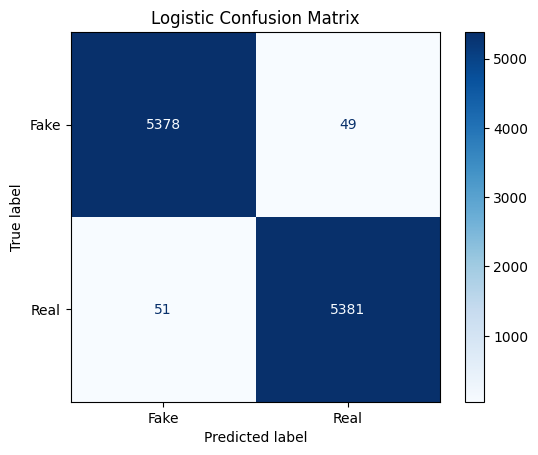

In [60]:
plot_confusion_matrix(tuned_log_model, X_test, y_test, "Logistic Confusion Matrix")

In [54]:
X = embedding(df_balanced)
y = df_balanced['label'].values

svm_model, X_train, X_test, y_train, y_test = train_model(X, y, "SVM")

In [55]:
evaluate_model(svm_model, X_test, y_test)

              precision    recall  f1-score   support

        fake       0.96      0.95      0.95      5427
        real       0.95      0.96      0.95      5432

    accuracy                           0.95     10859
   macro avg       0.95      0.95      0.95     10859
weighted avg       0.95      0.95      0.95     10859

Accuracy: 0.95


In [61]:
tuned_svm_model = tune_svm(X, y)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best SVM Params: {'C': 1, 'class_weight': 'balanced', 'max_iter': 5000}


In [62]:
evaluate_model(tuned_svm_model, X_test, y_test)

              precision    recall  f1-score   support

        fake       0.99      0.99      0.99      5427
        real       0.99      0.99      0.99      5432

    accuracy                           0.99     10859
   macro avg       0.99      0.99      0.99     10859
weighted avg       0.99      0.99      0.99     10859

Accuracy: 0.99


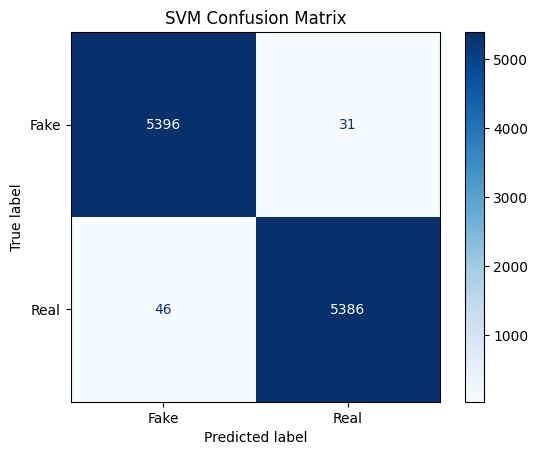

In [63]:
plot_confusion_matrix(tuned_svm_model, X_test, y_test, "SVM Confusion Matrix")